# Bachmannpreis Topic Modeling (2015–2024)

This notebook uses **BERTopic** with a German-language sentence transformer to discover and track thematic trends across the Ingeborg Bachmann Prize–winning texts from 2015 to 2024.

### Pipeline overview
1. Load & chunk texts into paragraph-level documents (10 full texts → hundreds of chunks)
2. Clean: remove German stop words, author/character names via spaCy NER
3. Embed with `paraphrase-multilingual-MiniLM-L12-v2`
4. Fit BERTopic with German-aware CountVectorizer
5. Visualise topics, distributions per text, and **topic trends over time**

## A

## 0 — Install dependencies
Run once; restart the kernel afterwards if needed.

In [1]:
!pip install bertopic sentence-transformers spacy pandas plotly scikit-learn hdbscan umap-learn
!python -m spacy download de_core_news_lg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 567.8/567.8 MB 19.9 MB/s  0:00:25:00:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('de_core_news_lg')


## 1 — Load data & chunking

BERTopic works best with many short documents. Since we only have 10 full texts, we split each into **paragraph-level chunks** (~3–5 sentences each), preserving the `year`, `author`, and `title` metadata for every chunk.

In [2]:
import pandas as pd
import re

# ── Load the CSV ──────────────────────────────────────────────────────────────
df_raw = pd.read_csv("bachmannpreis_texts.csv")
print(f"Loaded {len(df_raw)} texts spanning {df_raw['year'].min()}–{df_raw['year'].max()}")
df_raw[["year", "author", "title", "word_count"]]

Loaded 10 texts spanning 2015–2024


,year,author,title,word_count
0,2015,Nora Gomringer,Recherche,4119
1,2016,Sharon Dodua Otoo,Herr Gröttrup setzt sich hin,3184
2,2017,ferdinand schmalz,mein lieblingstier heißt winter,2791
3,2018,Tanja Maljartschuk,FRÖSCHE IM MEER,2827
4,2019,Birgit Birnbacher,Der Schrank,4060
5,2020,Helga Schubert,Vom Aufstehen,3918
6,2021,Nava Ebrahimi,DER COUSIN,4188
7,2022,Ana Marwan,WECHSELKRÖTE,3855
8,2023,Valeria Gordeev,ER PUTZT,2872
9,2024,Tijan Sila,"Der Tag, an dem meine Mutter verrückt wurde",2410


In [3]:
# ── Chunk each text into paragraphs ───────────────────────────────────────────
# Split on double-newlines (paragraph breaks) or fall back to ~3-sentence windows.

MIN_CHUNK_WORDS = 30  # drop very short fragments

rows = []
for _, row in df_raw.iterrows():
    text = row["text"]
    # Try paragraph split first
    paragraphs = re.split(r"\n{2,}", text)
    # If there are very few paragraph breaks, use sentence-window chunking
    if len(paragraphs) < 5:
        sentences = re.split(r"(?<=[.!?])\s+", text)
        window = 4  # sentences per chunk
        paragraphs = [
            " ".join(sentences[i : i + window])
            for i in range(0, len(sentences), window)
        ]
    for chunk in paragraphs:
        chunk = chunk.strip()
        if len(chunk.split()) >= MIN_CHUNK_WORDS:
            rows.append(
                {
                    "year": row["year"],
                    "author": row["author"],
                    "title": row["title"],
                    "chunk": chunk,
                }
            )

df = pd.DataFrame(rows)
print(f"{len(df)} chunks created from {df_raw.shape[0]} texts")
df.groupby(["year", "author"]).size().reset_index(name="chunks")

508 chunks created from 10 texts


,year,author,chunks
0,2015,Nora Gomringer,56
1,2016,Sharon Dodua Otoo,54
2,2017,ferdinand schmalz,39
3,2018,Tanja Maljartschuk,48
4,2019,Birgit Birnbacher,58
5,2020,Helga Schubert,55
6,2021,Nava Ebrahimi,81
7,2022,Ana Marwan,58
8,2023,Valeria Gordeev,22
9,2024,Tijan Sila,37


## 2 — Text cleaning: stop words & name removal

In [4]:
import spacy

# ── Load spaCy German model for NER ──────────────────────────────────────────
nlp = spacy.load("de_core_news_lg", disable=["parser"])

# ── Comprehensive German stop-word list ──────────────────────────────────────
# spaCy's built-in list + common extras that leak through in literary texts
GERMAN_STOP_WORDS = nlp.Defaults.stop_words | {
    "dass", "ja", "mal", "schon", "denn", "also", "doch", "noch",
    "gar", "ganz", "eben", "wohl", "dabei", "dabei", "vielleicht",
    "eigentlich", "natürlich", "nämlich", "überhaupt", "irgendwie",
    "irgendwann", "immerhin", "jedenfalls", "allerdings", "sozusagen",
    "wobei", "ohnehin", "insofern", "inzwischen", "damals", "darum",
    "ok", "hallo", "bitte", "herr", "frau",
}

# ── Known author + character names to always strip ───────────────────────────
KNOWN_NAMES = {
    n.lower()
    for n in [
        # Authors
        "Nora", "Gomringer", "Sharon", "Dodua", "Otoo", "ferdinand",
        "schmalz", "Tanja", "Maljartschuk", "Birgit", "Birnbacher",
        "Helga", "Schubert", "Nava", "Ebrahimi", "Ana", "Marwan",
        "Valeria", "Gordeev", "Tijan", "Sila",
        # Prominent fictional/referenced names in the texts
        "Bossong", "Gröttrup", "Irmi", "Ada", "Tobias", "Evelyn",
        "Petro", "Thomas", "Helmut", "Hans", "Kolja", "Natalka",
        "Franz", "Fabian", "Schlicht", "Schauer",
    ]
}

def clean_text(text: str) -> str:
    """Remove names (via NER + known list) and stop words from a German text."""
    doc = nlp(text)

    # Collect NER-detected person names
    ner_names = set()
    for ent in doc.ents:
        if ent.label_ == "PER":
            for tok in ent:
                ner_names.add(tok.text.lower())

    all_names = KNOWN_NAMES | ner_names

    tokens = []
    for tok in doc:
        word_lower = tok.text.lower()
        if tok.is_punct or tok.is_space:
            continue
        if word_lower in GERMAN_STOP_WORDS:
            continue
        if word_lower in all_names:
            continue
        if len(tok.text) < 2:
            continue
        tokens.append(tok.text)

    return " ".join(tokens)


print("Cleaning chunks (this may take a minute with the large spaCy model)…")
df["clean"] = df["chunk"].apply(clean_text)
print("Done.")

# Quick sanity check
df[["year", "author", "chunk", "clean"]].head(3)

Cleaning chunks (this may take a minute with the large spaCy model)…
Done.


,year,author,chunk,clean
0,2015,Nora Gomringer,Frau Terp lebt mit ihrer Tochter Evelyn im 5. ...,lebt Tochter 5. Stock Gönnerstraße 18. trägt r...
1,2015,Nora Gomringer,Sie soll knapp über dreißig sein. Sie sieht au...,knapp dreißig sieht knapp 12. Mama rufe Gesich...
2,2015,Nora Gomringer,"Eve, mach mal Platz und lass Frau Bossong here...",Eve mach Platz lass hereinkommen entlang rein ...


## 3 — BERTopic with a German embedding model

We use `paraphrase-multilingual-MiniLM-L12-v2`, a strong multilingual sentence-transformer that handles German well. The `CountVectorizer` also receives our stop-word list to keep topic keywords clean.

In [5]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from umap import UMAP
from hdbscan import HDBSCAN

# ── Embedding model ──────────────────────────────────────────────────────────
embedding_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

# ── German-aware vectorizer for topic-word extraction ─────────────────────────
vectorizer = CountVectorizer(
    stop_words=list(GERMAN_STOP_WORDS | KNOWN_NAMES),
    min_df=2,
    ngram_range=(1, 2),
)

# ── UMAP: lower n_neighbors for small corpora ────────────────────────────────
umap_model = UMAP(
    n_neighbors=10,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42,
)

# ── HDBSCAN: small min_cluster_size for a literary corpus ────────────────────
hdbscan_model = HDBSCAN(
    min_cluster_size=5,
    min_samples=2,
    metric="euclidean",
    prediction_data=True,
)

# ── Build BERTopic ────────────────────────────────────────────────────────────
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer,
    language="multilingual",
    top_n_words=10,
    nr_topics="auto",
    verbose=True,
)

docs = df["clean"].tolist()
topics, probs = topic_model.fit_transform(docs)
df["topic"] = topics

print(f"\nDiscovered {len(set(topics)) - (1 if -1 in topics else 0)} topics "
      f"({topics.count(-1)} chunks marked as outliers)")

/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|█| 199/199 [00:00<00:00, 1397.31it/s, Materializing param=
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-02-22 18:17:30,085 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████████████████████████████| 16/16 [00:04<00:00,  3.46it/s]
2026-02-22 18:17:34,726 - BERTopic - Embedding - Completed ✓
2026-02-22 18:17:34,726 - BERTopic - Dimensionality - Fitting the dimensionality


Discovered 27 topics (113 chunks marked as outliers)


## 4 — Explore discovered topics

In [6]:
# ── Topic overview table ─────────────────────────────────────────────────────
topic_info = topic_model.get_topic_info()
topic_info.head(20)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,113,-1_mutter_weiß_vater_cousin,"[mutter, weiß, vater, cousin, alt, augen, wuns...",[sitzt Freundin Fernseher schaut Emergency Roo...
1,0,169,0_mutter_schwester_vater_sagen,"[mutter, schwester, vater, sagen, mann, kind, ...",[Wohnung voller Mörder still brüllte Vater Mun...
2,1,19,1_beobachter_schweigen_steht_hand,"[beobachter, schweigen, steht, hand, rehragout...",[steht schweiß durchnässten eismannuniform tür...
3,2,17,2_sofort_autorin_autoren_rande,"[sofort, autorin, autoren, rande, roman, jegli...",[Roman rückblickend zusammengeklaubt neu zusam...
4,3,14,3_berlacovic_beobachter_hof_sage,"[berlacovic, beobachter, hof, sage, paar, könn...",[erklärt Medien Haus aufmerksam Gegend Fall be...
5,4,12,4_cousin_vorstellung_klatschen_bühnenrand,"[cousin, vorstellung, klatschen, bühnenrand, r...",[Vorstellung vorstellen Eingang halten inne Gl...
6,5,11,5_pool_wasser_meer_ufer,"[pool, wasser, meer, ufer, erinnerung, kröte, ...",[klein fühlen liebsten weggeweht Meer hinaus M...
7,6,10,6_bett_füße_sofa_türen,"[bett, füße, sofa, türen, weder, schlafzimmer,...",[weiß Sofa verbracht barfuß Wohnung umher hört...
8,7,9,7_gedanken_glaubt_entscheidung_wütend,"[gedanken, glaubt, entscheidung, wütend, sache...",[Gehör fremde Probleme tut Bestes Leuten egal ...
9,8,9,8_sag_mutter_manchmal_fragte,"[sag, mutter, manchmal, fragte, spürte, tränen...",[hörte Tür Schlafzimmer zuschlagen Mutter schü...


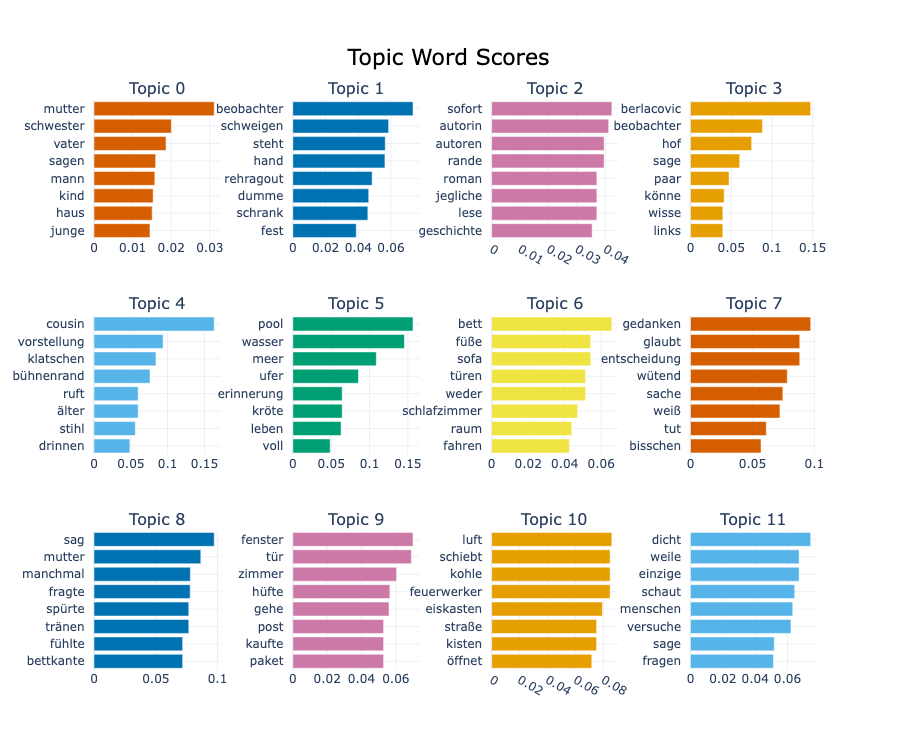

In [7]:
# ── Bar chart of top words per topic ─────────────────────────────────────────
topic_model.visualize_barchart(top_n_topics=12, n_words=8)

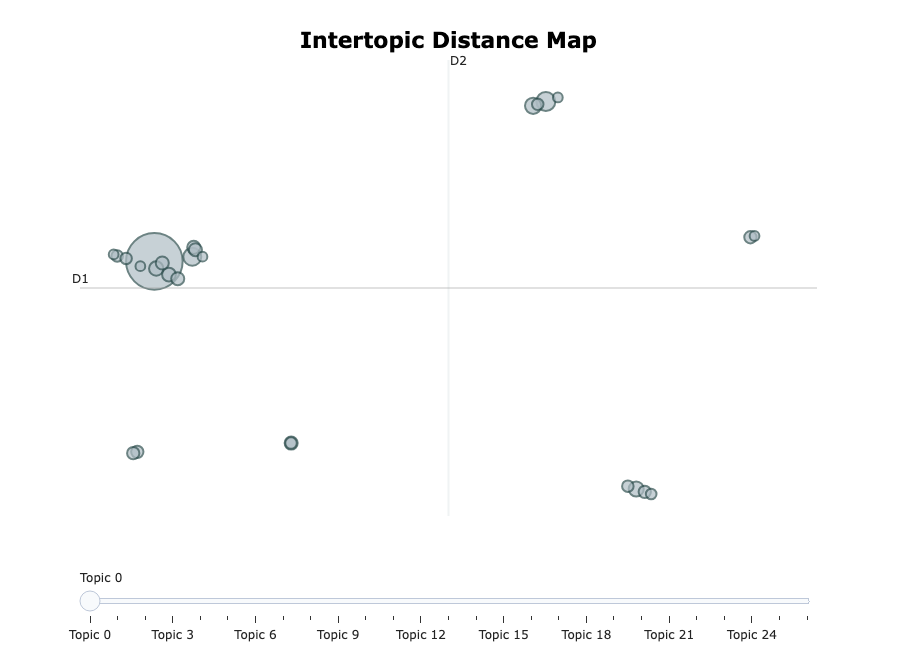

In [8]:
# ── Inter-topic distance map ─────────────────────────────────────────────────
topic_model.visualize_topics()

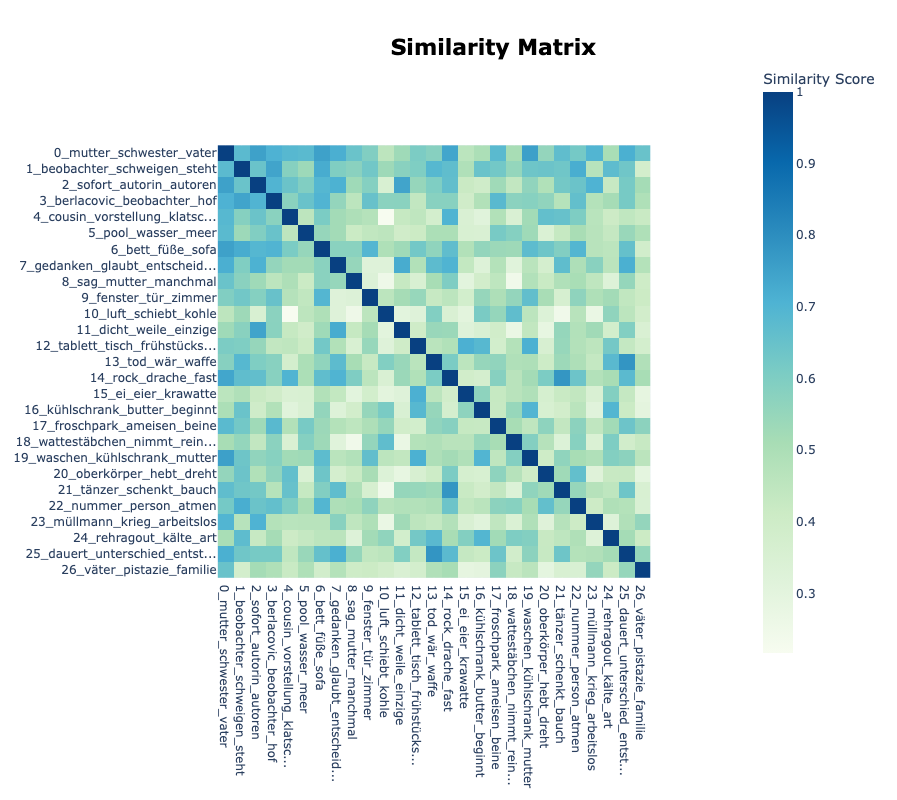

In [9]:
# ── Topic similarity heatmap ─────────────────────────────────────────────────
topic_model.visualize_heatmap()

## 5 — Topic distribution per text

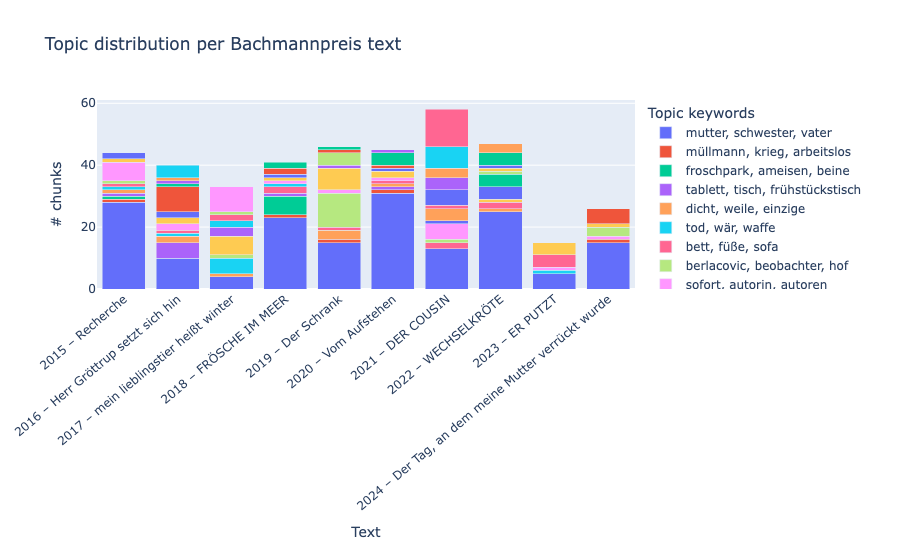

In [10]:
import plotly.express as px

# Count topic assignments per (year, title)
topic_by_text = (
    df[df["topic"] != -1]
    .groupby(["year", "title", "topic"])
    .size()
    .reset_index(name="count")
)
topic_by_text["topic_label"] = topic_by_text["topic"].apply(
    lambda t: ", ".join([w for w, _ in topic_model.get_topic(t)[:3]])
)
topic_by_text["text_label"] = (
    topic_by_text["year"].astype(str) + " – " + topic_by_text["title"]
)

fig = px.bar(
    topic_by_text.sort_values("year"),
    x="text_label",
    y="count",
    color="topic_label",
    title="Topic distribution per Bachmannpreis text",
    labels={"count": "# chunks", "text_label": "Text", "topic_label": "Topic keywords"},
    barmode="stack",
)
fig.update_layout(xaxis_tickangle=-40, height=550)
fig.show()

## 6 — Topic trends over time

BERTopic's `topics_over_time` aggregates topic prevalence per time bin, which here corresponds to the **year** the text won the prize.

In [11]:
# Create proper timestamps from years (BERTopic needs datetime objects)
timestamps = pd.to_datetime(df["year"], format="%Y").tolist()

topics_over_time = topic_model.topics_over_time(
    docs,
    timestamps,
    nr_bins=len(df["year"].unique()),  # one bin per year
    evolution_tuning=True,
    global_tuning=True,
)

topics_over_time.head(10)

10it [00:00, 109.77it/s]


,Topic,Words,Frequency,Timestamp
0,-1,"stock, polizei, autorin, gerät, stoppt",12,2014-12-28 17:06:43.200
1,0,"13, junge, schwester, jungen, autorin",28,2014-12-28 17:06:43.200
2,1,"beobachtet, kiemen, zähnen, ansehen, atmen",1,2014-12-28 17:06:43.200
3,2,"sofort, autorin, autoren, hab, letzten",6,2014-12-28 17:06:43.200
4,3,"23, informationen, versuche, nächsten, paar",1,2014-12-28 17:06:43.200
5,6,"leg, ausgabe, bedeckt, leben, bett",1,2014-12-28 17:06:43.200
6,7,"bisschen, einnehmen, anzieht, feiern, schlucken",2,2014-12-28 17:06:43.200
7,11,"terps, bleibe, plan, hinauf, öffnen",1,2014-12-28 17:06:43.200
8,12,"gespielt, weitermachen, fleisch, weiche, zähne",1,2014-12-28 17:06:43.200
9,13,"waffe, gegessen, wunderliche, handeln, tod",1,2014-12-28 17:06:43.200


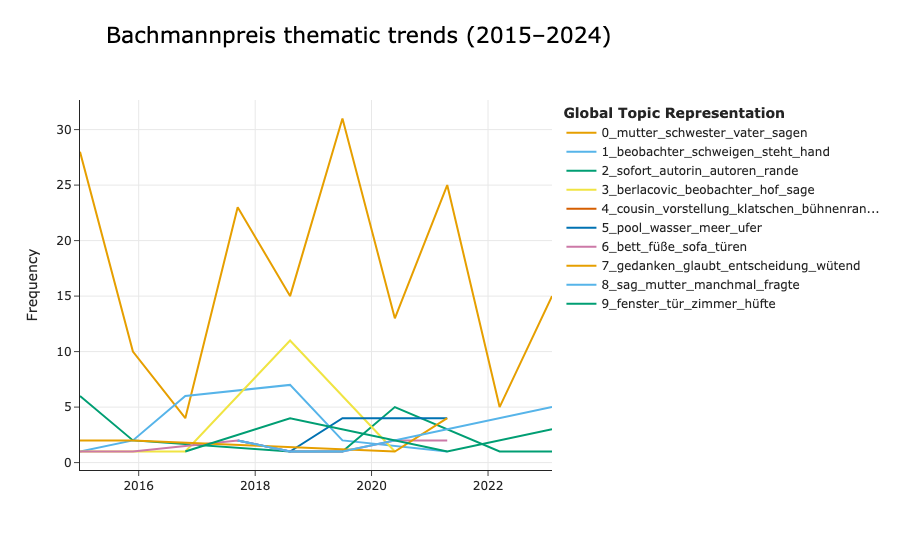

In [12]:
# ── Visualise topic trends ───────────────────────────────────────────────────
fig_over_time = topic_model.visualize_topics_over_time(
    topics_over_time,
    top_n_topics=10,
    title="Bachmannpreis thematic trends (2015–2024)",
)
fig_over_time.update_layout(height=550)
fig_over_time.show()

## 7 — Document-level UMAP projection

A 2-D scatter of every chunk, coloured by topic, with year/author hover info.

Batches: 100%|██████████████████████████████████| 16/16 [00:01<00:00,  9.49it/s]


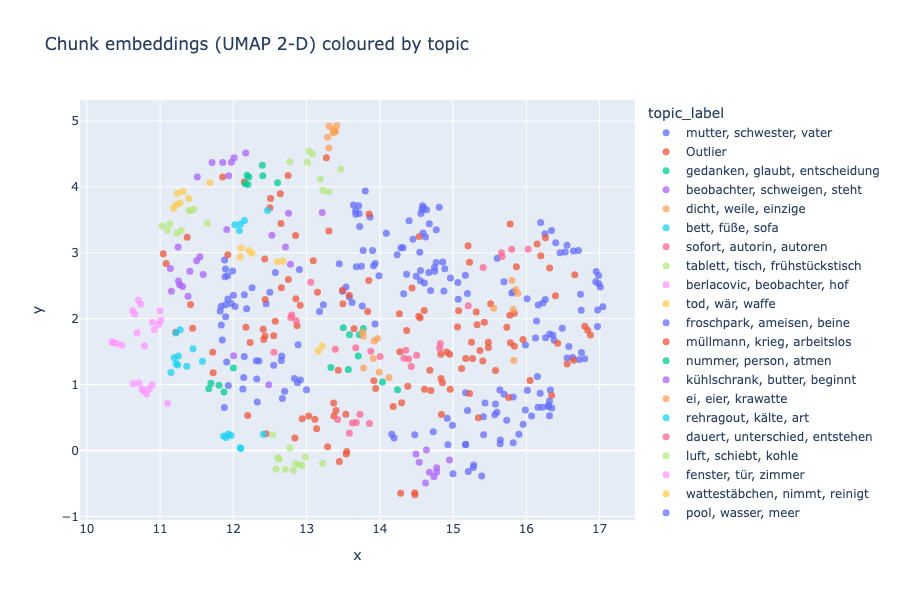

In [13]:
# ── 2-D document embeddings ──────────────────────────────────────────────────
embeddings = embedding_model.encode(docs, show_progress_bar=True)

from umap import UMAP as UMAP2D
reducer = UMAP2D(n_components=2, n_neighbors=10, min_dist=0.1,
                 metric="cosine", random_state=42)
coords = reducer.fit_transform(embeddings)

df["x"] = coords[:, 0]
df["y"] = coords[:, 1]
df["topic_label"] = df["topic"].apply(
    lambda t: (", ".join([w for w, _ in topic_model.get_topic(t)[:3]])
               if t != -1 else "Outlier")
)

fig_scatter = px.scatter(
    df,
    x="x", y="y",
    color="topic_label",
    hover_data=["year", "author", "title"],
    title="Chunk embeddings (UMAP 2-D) coloured by topic",
    width=850, height=600,
)
fig_scatter.update_traces(marker=dict(size=7, opacity=0.75))
fig_scatter.show()

## 8 — Per-topic representative passages

For interpretability, print the **most representative original chunk** for each topic.

In [14]:
for topic_id in sorted(df["topic"].unique()):
    if topic_id == -1:
        continue
    keywords = ", ".join([w for w, _ in topic_model.get_topic(topic_id)[:6]])
    subset = df[df["topic"] == topic_id]
    example = subset.iloc[0]
    print(f"\n{'='*80}")
    print(f"TOPIC {topic_id}  |  Keywords: {keywords}")
    print(f"Example from: {example['author']} ({example['year']}) — {example['title']}")
    print(f"-"*80)
    print(example["chunk"][:500] + "…" if len(example["chunk"]) > 500 else example["chunk"])
    print()


TOPIC 0  |  Keywords: mutter, schwester, vater, sagen, mann, kind
Example from: Nora Gomringer (2015) — Recherche
--------------------------------------------------------------------------------
Frau Terp lebt mit ihrer Tochter Evelyn im 5. Stock, Gönnerstraße 18. Sie trägt einen roten Mantel, als sie an unserer Tür klingelt. Und sie ist so schmal, dass ihr roter Mund wie ein breiter Briefschlitz in ihrem Gesicht aussieht.


TOPIC 1  |  Keywords: beobachter, schweigen, steht, hand, rehragout, dumme
Example from: Nora Gomringer (2015) — Recherche
--------------------------------------------------------------------------------
Und es steht ein Mann mit fischgrätigen Zähnen nahe der Erle, dessen Kiemen sich spreizen, der unter Wasser wie an Land atmen kann, den keiner kennt, den nur wenige sehen, wenn sie ihn ansehen. Einer, der viel Zeit hat. Und in diesem Übermaß an Zeit Menschen beobachtet. Manchmal auffrisst.


TOPIC 2  |  Keywords: sofort, autorin, autoren, rande, roman, jegliche
Ex

## 9 — Summary table: dominant topics per year

In [15]:
# For each year, find the most frequent non-outlier topic
summary = []
for year in sorted(df["year"].unique()):
    sub = df[(df["year"] == year) & (df["topic"] != -1)]
    if sub.empty:
        continue
    top_topic = sub["topic"].value_counts().index[0]
    keywords = ", ".join([w for w, _ in topic_model.get_topic(top_topic)[:5]])
    author = sub["author"].iloc[0]
    title = sub["title"].iloc[0]
    summary.append({
        "Year": year,
        "Author": author,
        "Title": title,
        "Dominant topic": top_topic,
        "Topic keywords": keywords,
    })

df_summary = pd.DataFrame(summary)
df_summary

,Year,Author,Title,Dominant topic,Topic keywords
0,2015,Nora Gomringer,Recherche,0,"mutter, schwester, vater, sagen, mann"
1,2016,Sharon Dodua Otoo,Herr Gröttrup setzt sich hin,0,"mutter, schwester, vater, sagen, mann"
2,2017,ferdinand schmalz,mein lieblingstier heißt winter,10,"luft, schiebt, kohle, feuerwerker, eiskasten"
3,2018,Tanja Maljartschuk,FRÖSCHE IM MEER,0,"mutter, schwester, vater, sagen, mann"
4,2019,Birgit Birnbacher,Der Schrank,0,"mutter, schwester, vater, sagen, mann"
5,2020,Helga Schubert,Vom Aufstehen,0,"mutter, schwester, vater, sagen, mann"
6,2021,Nava Ebrahimi,DER COUSIN,0,"mutter, schwester, vater, sagen, mann"
7,2022,Ana Marwan,WECHSELKRÖTE,0,"mutter, schwester, vater, sagen, mann"
8,2023,Valeria Gordeev,ER PUTZT,0,"mutter, schwester, vater, sagen, mann"
9,2024,Tijan Sila,"Der Tag, an dem meine Mutter verrückt wurde",0,"mutter, schwester, vater, sagen, mann"


---
### Notes
- **Corpus size**: 10 texts / ~200–400 chunks is small for topic modeling. Expect some noise; topics may overlap. Tuning `min_cluster_size`, `n_neighbors`, and `nr_topics` can help.
- **Name leakage**: We combine spaCy NER with a manual name list. You can extend `KNOWN_NAMES` if new character names leak into keywords.
- **Alternative models**: For even better German embeddings, try `T-Systems-onsite/cross-en-de-roberta-sentence-transformer` or `deutsche-telekom/gbert-large-paraphrase-cosine`.